In [38]:
from pathlib import Path

print(Path().cwd())

/home/gruengroup/christian/Projects/notebook_repository/notebooks/2026-04-24T06-54-05Z


In [39]:
import socket

print(f"Current Node: {socket.gethostname()}")

Current Node: pikachu


In [40]:
import itertools
import logging
from pathlib import Path
from typing import Any, Callable, Sequence

import matplotlib.pyplot as plt
import mlflow
import nico2_lib as n2l
import numpy as np
import pandas as pd
import plotly.express as px
import polars as pl
import scanpy as sc
import scipy
import seaborn as sns
from experiment import Celltype, Dataset, Model, NumericArray, Result, Sample
from numpy import number
from sqlalchemy import event
from sqlalchemy.engine import Engine
from sqlmodel import Session, create_engine, select
from tqdm import tqdm

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

In [4]:
exp_name = "Default"
benchmark_experiment = mlflow.get_experiment_by_name(exp_name)
if not benchmark_experiment:
    raise ValueError(f"Experiment '{exp_name}' not found.")
runs = mlflow.search_runs(experiment_ids=[benchmark_experiment.experiment_id])
if runs.empty:
    raise RuntimeError(f"No runs found in experiment '{exp_name}'.")
last_run_id = runs.sort_values("start_time", ascending=False)["run_id"].iloc[0]
logger.info(f"Using run_id: {last_run_id}")
logger.info("Downloading 'database.db'...")
database_path = mlflow.artifacts.download_artifacts(
    run_id=last_run_id, artifact_path="database.db"
)
logger.info(f"Local path: {database_path}")
sqlite_url = f"sqlite:///{database_path}"
engine = create_engine(sqlite_url, echo=False)
logger.info("Database engine initialized.")

INFO: Using run_id: ac981ca6cbd8465680b54609c7ba5bde
INFO: Downloading 'database.db'...


INFO: Local path: /tmp/tmpyhrnv0m_/database.db
INFO: Database engine initialized.


In [5]:
# database_path = "/Users/egerc/Documents/Projects/notebook_repository/notebooks/2026-03-11T09-44-10Z/database.db"
# database_path = Path().cwd() / "database.db"
logger.info(f"Local path: {database_path}")
sqlite_url = f"sqlite:///{database_path}"
engine = create_engine(sqlite_url, echo=False)
logger.info("Database engine initialized.")

INFO: Local path: /tmp/tmpyhrnv0m_/database.db
INFO: Database engine initialized.


## Embedding Feature Autocorrelation

In [6]:
def _create_avg_pairwise_metric_fn(
    metric_fn: Callable[[NumericArray, NumericArray], float],
) -> Callable[[NumericArray], float]:
    def pairwise_metric_fn(
        features: NumericArray,
    ) -> float:
        eps = 1e-8
        return np.array(
            [
                metric_fn(a + eps, b + eps)
                for a, b in itertools.combinations(features.T, 2)
            ]
        ).mean()

    return pairwise_metric_fn


def create_embedding_evaluator(
    correlation_func: Callable[[NumericArray, NumericArray], float],
) -> Callable[[Result], tuple[float, float, float, float]]:
    average_pairwise_correlation_func = _create_avg_pairwise_metric_fn(
        metric_fn=correlation_func
    )

    def pairwise_correlation_func(
        result: Result,
    ) -> tuple[float, float, float, float]:
        results: tuple[float, float, float, float] = tuple(
            [
                average_pairwise_correlation_func(embedding)
                for embedding in [
                    result.global_model_embedding_reference,
                    result.global_model_embedding_query,
                    result.celltype_model_embedding_reference,
                    result.celltype_model_embedding_query,
                ]
            ]
        )
        return results

    return pairwise_correlation_func

## Embedding Structure

In [7]:
def create_embedding_structure_evaluator(
    structure_function: Callable[[NumericArray, NumericArray], float],
) -> Callable[[Result], tuple[float, float, float, float]]:
    def structure_evaluator(
        result: Result,
    ) -> tuple[float, float, float, float]:
        return (
            structure_function(
                result.celltype.reference_adjacency_matrix,
                result.global_model_embedding_reference,
            ),
            structure_function(
                result.celltype.query_adjacency_matrix,
                result.global_model_embedding_query,
            ),
            structure_function(
                result.celltype.reference_adjacency_matrix,
                result.celltype_model_embedding_reference,
            ),
            structure_function(
                result.celltype.query_adjacency_matrix,
                result.celltype_model_embedding_query,
            ),
        )

    return structure_evaluator


def compute_multivariate_geary(
    adjacency: NumericArray,
    embeddings: NumericArray,
) -> float:
    """
    A direct multivariate version of Geary's C.
    Computes Euclidean distance in embedding space weighted by graph adjacency.
    """
    n, d = embeddings.shape
    w_sum = np.sum(adjacency)
    if w_sum == 0:
        return 0.0

    # Variance normalization (denominator)
    # We sum the variance of each feature column
    variance_sum = np.sum(np.var(embeddings, axis=0))
    if variance_sum == 0:
        return 0.0

    # Calculate weighted squared Euclidean distances between all neighbors
    # Using a memory-efficient approach for large n:
    # dist(i,j)^2 = ||xi||^2 + ||xj||^2 - 2<xi, xj>
    norms = np.sum(embeddings**2, axis=1)
    dist_sq = (
        norms[:, np.newaxis]
        + norms[np.newaxis, :]
        - 2 * np.dot(embeddings, embeddings.T)
    )

    numerator = np.sum(adjacency * dist_sq)
    denominator = 2 * w_sum * variance_sum

    return float(((n - 1) * numerator) / (n * denominator))


def blabla(
    func: Callable[[NumericArray, NumericArray], float],
) -> Callable[[NumericArray, NumericArray], float]:
    def blabla2(adjacency: NumericArray, embeddings: NumericArray) -> float:
        # 1. Identify non-zero columns (features)
        # We check if the absolute sum of the column is > 0
        non_zero_mask = np.any(embeddings != 0, axis=0)
        valid_features = embeddings[:, non_zero_mask]

        # 2. Guard against the case where NO features are non-zero
        if valid_features.shape[1] == 0:
            return 0.0

        # 3. Compute only for valid latent features
        scores = [func(adjacency, feature) for feature in valid_features.T]

        return float(np.mean(scores))

    return blabla2


def manual_morans_i(
    adjacency: NumericArray,
    feature: NumericArray,
) -> float:
    """
    Standard Moran's I: I = (n/W) * (z'Wz / z'z)
    Range: [-1, 1]. > 0 is clustered, < 0 is dispersed.
    """
    n = len(feature)
    z = feature - np.mean(feature)
    sum_sq_z = np.sum(z**2)

    if sum_sq_z == 0:
        return 0.0

    w_z = adjacency @ z
    numerator = z @ w_z

    w_sum = np.sum(adjacency)
    if w_sum == 0:
        return 0.0

    return float((n / w_sum) * (numerator / sum_sq_z))

## Cell wise sparsity

In [8]:
def gini(arr: NumericArray) -> float:
    """Compute Gini coefficient of a 1D array."""
    if np.amin(arr) < 0:
        arr -= np.amin(arr)  # Values must be non-negative
    arr = np.sort(arr)
    index = np.arange(1, arr.shape[0] + 1)
    n = arr.shape[0]
    return float((np.sum((2 * index - n - 1) * arr)) / (n * np.sum(arr)))


def entropy(arr: NumericArray) -> float:
    return float(scipy.stats.entropy(arr))


def kurtosis(arr: NumericArray) -> float:
    return float(scipy.stats.kurtosis(arr))


def skew(arr: NumericArray) -> float:
    return float(scipy.stats.skew(arr))


def make_aggregate_cellwise_metric_func(
    func: Callable[[NumericArray], float],
) -> Callable[[NumericArray], float]:
    def aggregate_cellwise_metric_func(arr: NumericArray) -> float:
        return float(np.mean([func(cell) for cell in arr]))

    return aggregate_cellwise_metric_func


def create_embedding_sparsity_evaluator(
    sparsity_func: Callable[[NumericArray], float],
) -> Callable[[Result], tuple[float, float, float, float]]:
    def embedding_sparsity_evaluator(
        result: Result,
    ) -> tuple[float, float, float, float]:
        embedding_sparsity_func = make_aggregate_cellwise_metric_func(
            sparsity_func,
        )
        return (
            embedding_sparsity_func(result.global_model_embedding_reference),
            embedding_sparsity_func(result.global_model_embedding_query),
            embedding_sparsity_func(result.celltype_model_embedding_reference),
            embedding_sparsity_func(result.celltype_model_embedding_query),
        )

    return embedding_sparsity_evaluator

## Coverage sparsity

In [9]:
def make_max_aggregate_featurewise_metric_func(
    func: Callable[[NumericArray], float],
) -> Callable[[NumericArray], float]:

    def aggregate_cellwise_metric_func(arr: NumericArray) -> float:
        return float(func(np.max(arr, axis=1)))

    return aggregate_cellwise_metric_func


def create_coverage_sparsity_evaluator(
    sparsity_func: Callable[[NumericArray], float],
) -> Callable[[Result], tuple[float, float, float, float]]:
    def coverage_sparsity_evaluator(
        result: Result,
    ) -> tuple[float, float, float, float]:
        max_agg_sparsity_func = make_max_aggregate_featurewise_metric_func(
            sparsity_func,
        )
        return (
            max_agg_sparsity_func(result.global_model_embedding_reference),
            max_agg_sparsity_func(result.global_model_embedding_query),
            max_agg_sparsity_func(result.celltype_model_embedding_reference),
            max_agg_sparsity_func(result.celltype_model_embedding_query),
        )

    return coverage_sparsity_evaluator

## Post-hoc interpretability

In [10]:
import gseapy

In [11]:
from functools import reduce, cache
from numpy.typing import NDArray

from sklearn.metrics.pairwise import cosine_similarity

GeneProgramsDB = frozenset[tuple[str, frozenset[str]]]


@cache
def get_gene_programs_db(
    name: str,
) -> GeneProgramsDB:
    library: dict[str, list[str]] = gseapy.get_library(  # type: ignore
        name=name,
    )
    return frozenset((program, frozenset(genes)) for program, genes in library.items())


def extract_gene_list(gene_programs_db: GeneProgramsDB) -> list[str]:
    return sorted(
        list(
            reduce(
                frozenset.union,
                [gene_set for _, gene_set in gene_programs_db],
                frozenset(),
            )
        )
    )


def get_gene_program_counts(
    gene_programs_db: GeneProgramsDB,
    genes: Sequence[str],
) -> NumericArray:
    binary_matrix = [
        [1 if gene in program_genes else 0 for gene in genes]
        for _, program_genes in gene_programs_db
    ]
    return np.array(binary_matrix)


def compute_factor_gene_correlations(
    x: NumericArray,
    w: NumericArray,
    corr_func: Callable[[NumericArray, NumericArray], float],
) -> NumericArray:
    return np.array(
        [
            [
                corr_func(factor_distribution.flatten(), gene_distribution.flatten())
                for factor_distribution in w.T
            ]
            for gene_distribution in x.T
        ]
    ).T


def max_cosine_alignment_scoring(
    factor_gene_loadings: NumericArray,
    gene_program_counts: NumericArray,
) -> float:
    """Calculate the average maximum cosine similarity between factors and databases.

    Reasoning:
        Dominic scoring relies on API hits and hard boundaries (top 10 genes), which
        discards the nuances of sub-dominant gene weights. This function compares the
        entire continuous vector of factor weights against the ground-truth binary vectors
        of the gene database using cosine similarity.

        By identifying the maximum cosine similarity score for each factor against
        the database, we measure how well the continuous distribution matches the
        shape of known biological modules without losing information to arbitrary thresholds.
        It scales beautifully from 0 to 1 and requires zero network requests.
    """
    similarity_matrix = cosine_similarity(factor_gene_loadings, gene_program_counts)
    max_similarities = np.max(similarity_matrix, axis=1)
    return float(np.mean(max_similarities))


def enrichment_score_evaluator(result: Result) -> tuple[float, float, float, float]:
    enrichment_db_name = "KEGG_2026"
    gene_programs_db = get_gene_programs_db(name=enrichment_db_name)
    database_gene_names = extract_gene_list(gene_programs_db=gene_programs_db)
    dataset_gene_names = [
        gene.upper() for gene in result.sample.dataset.shared_features
    ]
    genes: list[str] = np.intersect1d(database_gene_names, dataset_gene_names).tolist()
    gene_program_counts = get_gene_program_counts(
        gene_programs_db=gene_programs_db, genes=genes
    )

    feature_idx: NDArray[np.intp] = np.where(np.isin(dataset_gene_names, genes))[0]

    def abc(x: NumericArray, w: NumericArray) -> float:
        factor_gene_correlations = compute_factor_gene_correlations(
            x=x,
            w=w,
            corr_func=n2l.mt.pearson_metric,  # type: ignore
        )
        factor_gene_correlations = np.nan_to_num(factor_gene_correlations)
        return max_cosine_alignment_scoring(
            factor_gene_loadings=factor_gene_correlations,
            gene_program_counts=gene_program_counts,
        )

    return (
        abc(
            result.celltype.reference_counts_matrix[:, feature_idx],
            result.global_model_embedding_reference,
        ),
        abc(
            result.celltype.query_counts_matrix[:, feature_idx],
            result.global_model_embedding_query,
        ),
        abc(
            result.celltype.reference_counts_matrix[:, feature_idx],
            result.celltype_model_embedding_reference,
        ),
        abc(
            result.celltype.query_counts_matrix[:, feature_idx],
            result.celltype_model_embedding_query,
        ),
    )


In [12]:
def identity(x: float) -> float:
    return x


def tent(x: float) -> float:
    return -np.absolute(x)


def negative(x: float) -> float:
    return -x


In [13]:
METRIC_FNS: dict[
    str,
    dict[
        str,
        tuple[
            Callable[[Result], tuple[float, float, float, float]],
            Callable[[float], float],
        ],
    ],
] = {
    "embedding_autocorrelation": {
        "pearsonr": (create_embedding_evaluator(n2l.mt.pearson_metric), tent),
        "spearmanr": (
            create_embedding_evaluator(n2l.mt.spearman_metric),
            tent,
        ),
    },
    "embedding_structure": {
        "multivariate_gearys_c": (
            create_embedding_structure_evaluator(compute_multivariate_geary),
            negative,
        ),
        "morans_i": (
            create_embedding_structure_evaluator(blabla(manual_morans_i)),
            identity,
        ),
    },
    "embedding_sparsity": {
        "gini": (create_embedding_sparsity_evaluator(gini), identity),
        "entropy": (create_embedding_sparsity_evaluator(entropy), negative),
    },
    "coverage_sparsity": {
        "gini": (create_coverage_sparsity_evaluator(gini), negative),
        "entropy": (create_coverage_sparsity_evaluator(entropy), identity),
    },
    "biological_enrichment": {
        "max_cosine_alignment": (enrichment_score_evaluator, identity)
    },
}

In [14]:
with Session(engine) as session:
    result = session.exec(select(Result)).first()
    enr_score = enrichment_score_evaluator(result)


INFO: Downloading and generating Enrichr library gene sets...


In [15]:
import logging

# Silence all SQLAlchemy engine logs
logging.getLogger('sqlalchemy.engine').setLevel(logging.WARNING)

# If you still see some noise, silence the pools too
logging.getLogger('sqlalchemy.pool').setLevel(logging.WARNING)

In [17]:
from itertools import product
from tqdm import tqdm
from joblib import Memory
memory = Memory("./cache")

with Session(engine) as session:
    results = session.exec(select(Result).limit(500)).all()
    rows: list[dict[str, Any]] = []
    for result in tqdm(results):
        for metric_category, function_mapping in METRIC_FNS.items():
            for function_name, (
                metric_function,
                transformation_function,
            ) in function_mapping.items():
                metrics = 0.1, 0.2, 0.3, 0.4
                for value, (model_scope, dataset_split) in zip(
                    metrics, product(["global", "celltype"], ["reference", "query"])
                ):
                    rows.append(
                        {
                            "dataset_name": result.celltype.dataset.name,
                            "celltype": result.celltype.name,
                            "sample_id": result.sample.id_of_sample,
                            "model_name": result.model.name,
                            "metric_category": metric_category,
                            "function_name": function_name,
                            "model_scope": model_scope,
                            "dataset_split": dataset_split,
                            "value": value,
                            "value_transformed": transformation_function(value),
                        }
                    )
    results_df = pd.DataFrame(rows)

100%|████████████████████████████████████████████████████████████| 315/315 [00:00<00:00, 3153.03it/s]


In [91]:
results_df = pd.read_csv("/home/gruengroup/christian/Projects/notebook_repository/notebooks/2026-04-24T06-54-05Z/benchmarking_output.csv")

In [82]:
df = (
    results_df.groupby(
        [
            "model_name",
            "metric_category",
            "sample_id",
            "function_name",
            "dataset_name",
            "model_scope",
        ]
    )
    .agg({"value": "mean"})
    .reset_index()
)

In [56]:
results_df.query("function_name == 'morans_i'")

,Unnamed: 0,dataset_name,celltype,sample_id,model_name,metric_category,function_name,model_scope,dataset_split,value,value_transformed
12,12,Mouse Intestine Spatial,BZE,0,"NMF (3 Komponenten, Log Transform, Pre-Init)",embedding_structure,morans_i,global,reference,288.841068,288.841068
13,13,Mouse Intestine Spatial,BZE,0,"NMF (3 Komponenten, Log Transform, Pre-Init)",embedding_structure,morans_i,global,query,812.333357,812.333357
14,14,Mouse Intestine Spatial,BZE,0,"NMF (3 Komponenten, Log Transform, Pre-Init)",embedding_structure,morans_i,celltype,reference,284.933358,284.933358
15,15,Mouse Intestine Spatial,BZE,0,"NMF (3 Komponenten, Log Transform, Pre-Init)",embedding_structure,morans_i,celltype,query,803.932806,803.932806
48,48,Mouse Intestine Spatial,BZE,0,"PCA (3 Komponenten, Log Transform)",embedding_structure,morans_i,global,reference,287.962439,287.962439
...,...,...,...,...,...,...,...,...,...,...,...
11283,11283,Jennifer Spatial,pDC,0,"NMF (3 Komponenten, Log Transform)",embedding_structure,morans_i,celltype,query,113.120864,113.120864
11316,11316,Jennifer Spatial,pDC,0,"SCVI (3 Komponenten, Raw Counts)",embedding_structure,morans_i,global,reference,254.628884,254.628884
11317,11317,Jennifer Spatial,pDC,0,"SCVI (3 Komponenten, Raw Counts)",embedding_structure,morans_i,global,query,136.549889,136.549889
11318,11318,Jennifer Spatial,pDC,0,"SCVI (3 Komponenten, Raw Counts)",embedding_structure,morans_i,celltype,reference,266.852898,266.852898


In [92]:
results_df["dataset split | model scope"] = (
    results_df["dataset_split"] + " | " + results_df["model_scope"]
)
results_df["metric function"] = (
    results_df["metric_category"] + " | " + results_df["function_name"]
)

In [84]:
results_df

,Unnamed: 0,dataset_name,celltype,sample_id,model_name,metric_category,function_name,model_scope,dataset_split,value,value_transformed,dataset split | model scope,metric function
0,0,Mouse Intestine Spatial,BZE,0,"NMF (3 Komponenten, Log Transform, Pre-Init)",embedding_autocorrelation,pearsonr,global,reference,-0.021862,-0.021862,reference | global,embedding_autocorrelation | pearsonr
1,1,Mouse Intestine Spatial,BZE,0,"NMF (3 Komponenten, Log Transform, Pre-Init)",embedding_autocorrelation,pearsonr,global,query,0.201396,-0.201396,query | global,embedding_autocorrelation | pearsonr
2,2,Mouse Intestine Spatial,BZE,0,"NMF (3 Komponenten, Log Transform, Pre-Init)",embedding_autocorrelation,pearsonr,celltype,reference,-0.274759,-0.274759,reference | celltype,embedding_autocorrelation | pearsonr
3,3,Mouse Intestine Spatial,BZE,0,"NMF (3 Komponenten, Log Transform, Pre-Init)",embedding_autocorrelation,pearsonr,celltype,query,0.054639,-0.054639,query | celltype,embedding_autocorrelation | pearsonr
4,4,Mouse Intestine Spatial,BZE,0,"NMF (3 Komponenten, Log Transform, Pre-Init)",embedding_autocorrelation,spearmanr,global,reference,-0.078123,-0.078123,reference | global,embedding_autocorrelation | spearmanr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11335,11335,Jennifer Spatial,pDC,0,"SCVI (3 Komponenten, Raw Counts)",coverage_sparsity,entropy,celltype,query,0.256633,0.256633,query | celltype,coverage_sparsity | entropy
11336,11336,Jennifer Spatial,pDC,0,"SCVI (3 Komponenten, Raw Counts)",biological_enrichment,max_cosine_alignment,global,reference,0.000000,0.000000,reference | global,biological_enrichment | max_cosine_alignment
11337,11337,Jennifer Spatial,pDC,0,"SCVI (3 Komponenten, Raw Counts)",biological_enrichment,max_cosine_alignment,global,query,0.000000,0.000000,query | global,biological_enrichment | max_cosine_alignment
11338,11338,Jennifer Spatial,pDC,0,"SCVI (3 Komponenten, Raw Counts)",biological_enrichment,max_cosine_alignment,celltype,reference,0.000000,0.000000,reference | celltype,biological_enrichment | max_cosine_alignment


In [90]:
results_df.query("metric_category == 'coverage_sparsity'")

,Unnamed: 0,dataset_name,celltype,sample_id,model_name,metric_category,function_name,model_scope,dataset_split,value,value_transformed,dataset split | model scope,metric function
24,24,Mouse Intestine Spatial,BZE,0,"NMF (3 Komponenten, Log Transform, Pre-Init)",coverage_sparsity,gini,global,reference,0.159169,-0.159169,reference | global,coverage_sparsity | gini
25,25,Mouse Intestine Spatial,BZE,0,"NMF (3 Komponenten, Log Transform, Pre-Init)",coverage_sparsity,gini,global,query,0.274543,-0.274543,query | global,coverage_sparsity | gini
26,26,Mouse Intestine Spatial,BZE,0,"NMF (3 Komponenten, Log Transform, Pre-Init)",coverage_sparsity,gini,celltype,reference,0.177805,-0.177805,reference | celltype,coverage_sparsity | gini
27,27,Mouse Intestine Spatial,BZE,0,"NMF (3 Komponenten, Log Transform, Pre-Init)",coverage_sparsity,gini,celltype,query,0.294655,-0.294655,query | celltype,coverage_sparsity | gini
28,28,Mouse Intestine Spatial,BZE,0,"NMF (3 Komponenten, Log Transform, Pre-Init)",coverage_sparsity,entropy,global,reference,0.159169,0.159169,reference | global,coverage_sparsity | entropy
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11331,11331,Jennifer Spatial,pDC,0,"SCVI (3 Komponenten, Raw Counts)",coverage_sparsity,gini,celltype,query,0.256633,-0.256633,query | celltype,coverage_sparsity | gini
11332,11332,Jennifer Spatial,pDC,0,"SCVI (3 Komponenten, Raw Counts)",coverage_sparsity,entropy,global,reference,0.202576,0.202576,reference | global,coverage_sparsity | entropy
11333,11333,Jennifer Spatial,pDC,0,"SCVI (3 Komponenten, Raw Counts)",coverage_sparsity,entropy,global,query,0.247439,0.247439,query | global,coverage_sparsity | entropy
11334,11334,Jennifer Spatial,pDC,0,"SCVI (3 Komponenten, Raw Counts)",coverage_sparsity,entropy,celltype,reference,0.107928,0.107928,reference | celltype,coverage_sparsity | entropy


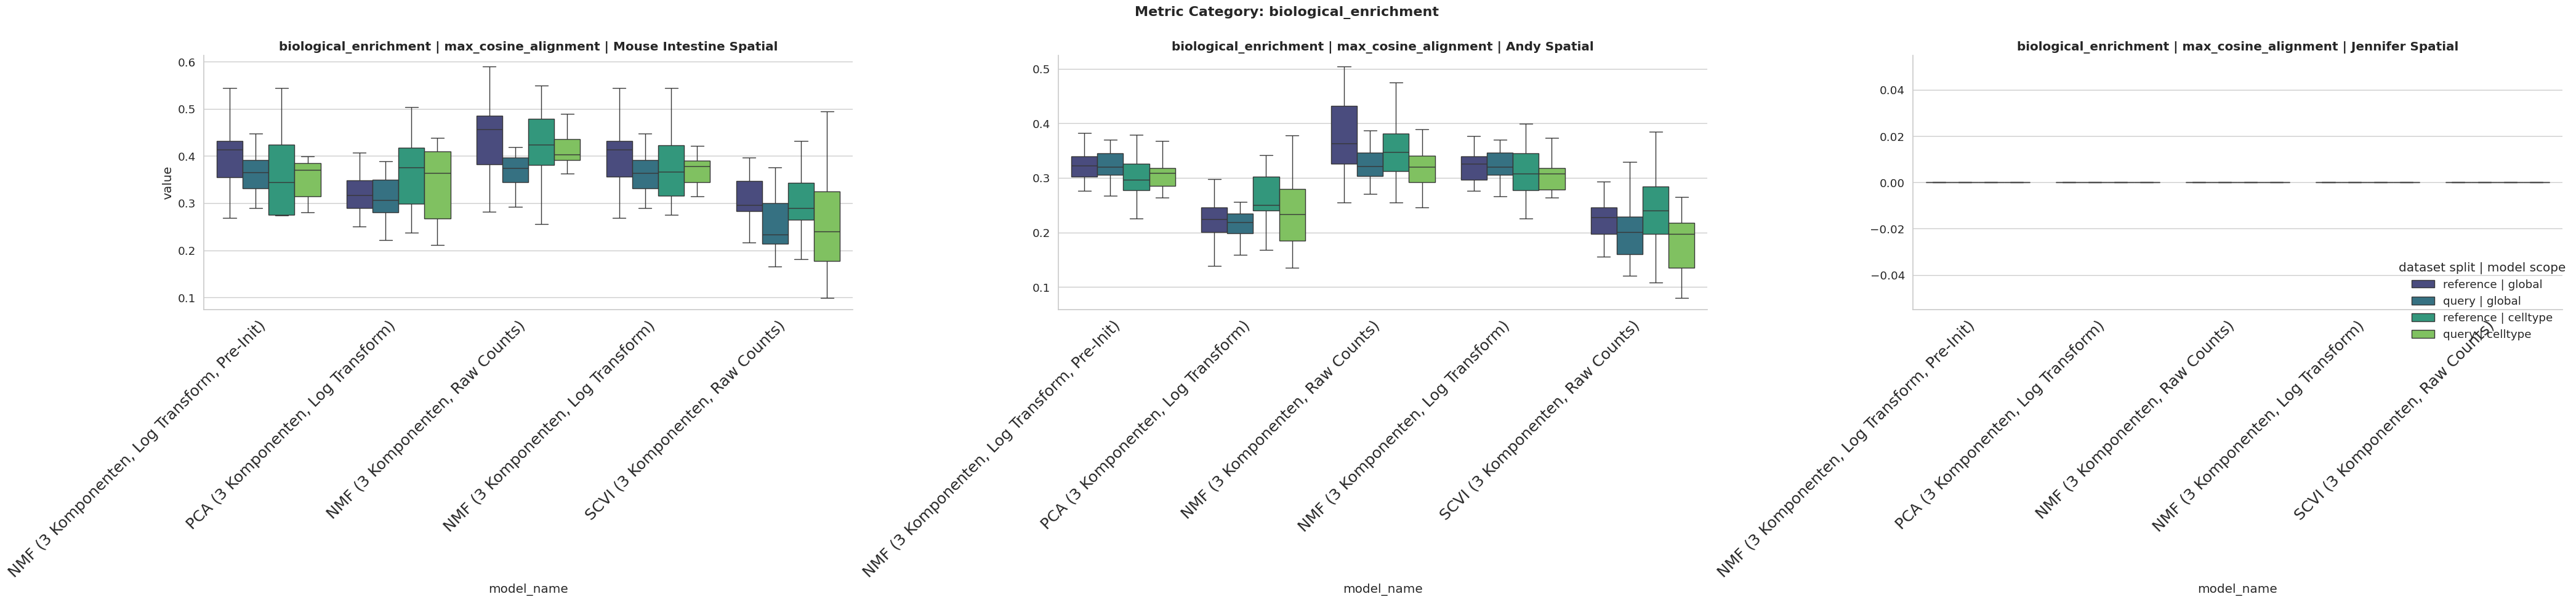

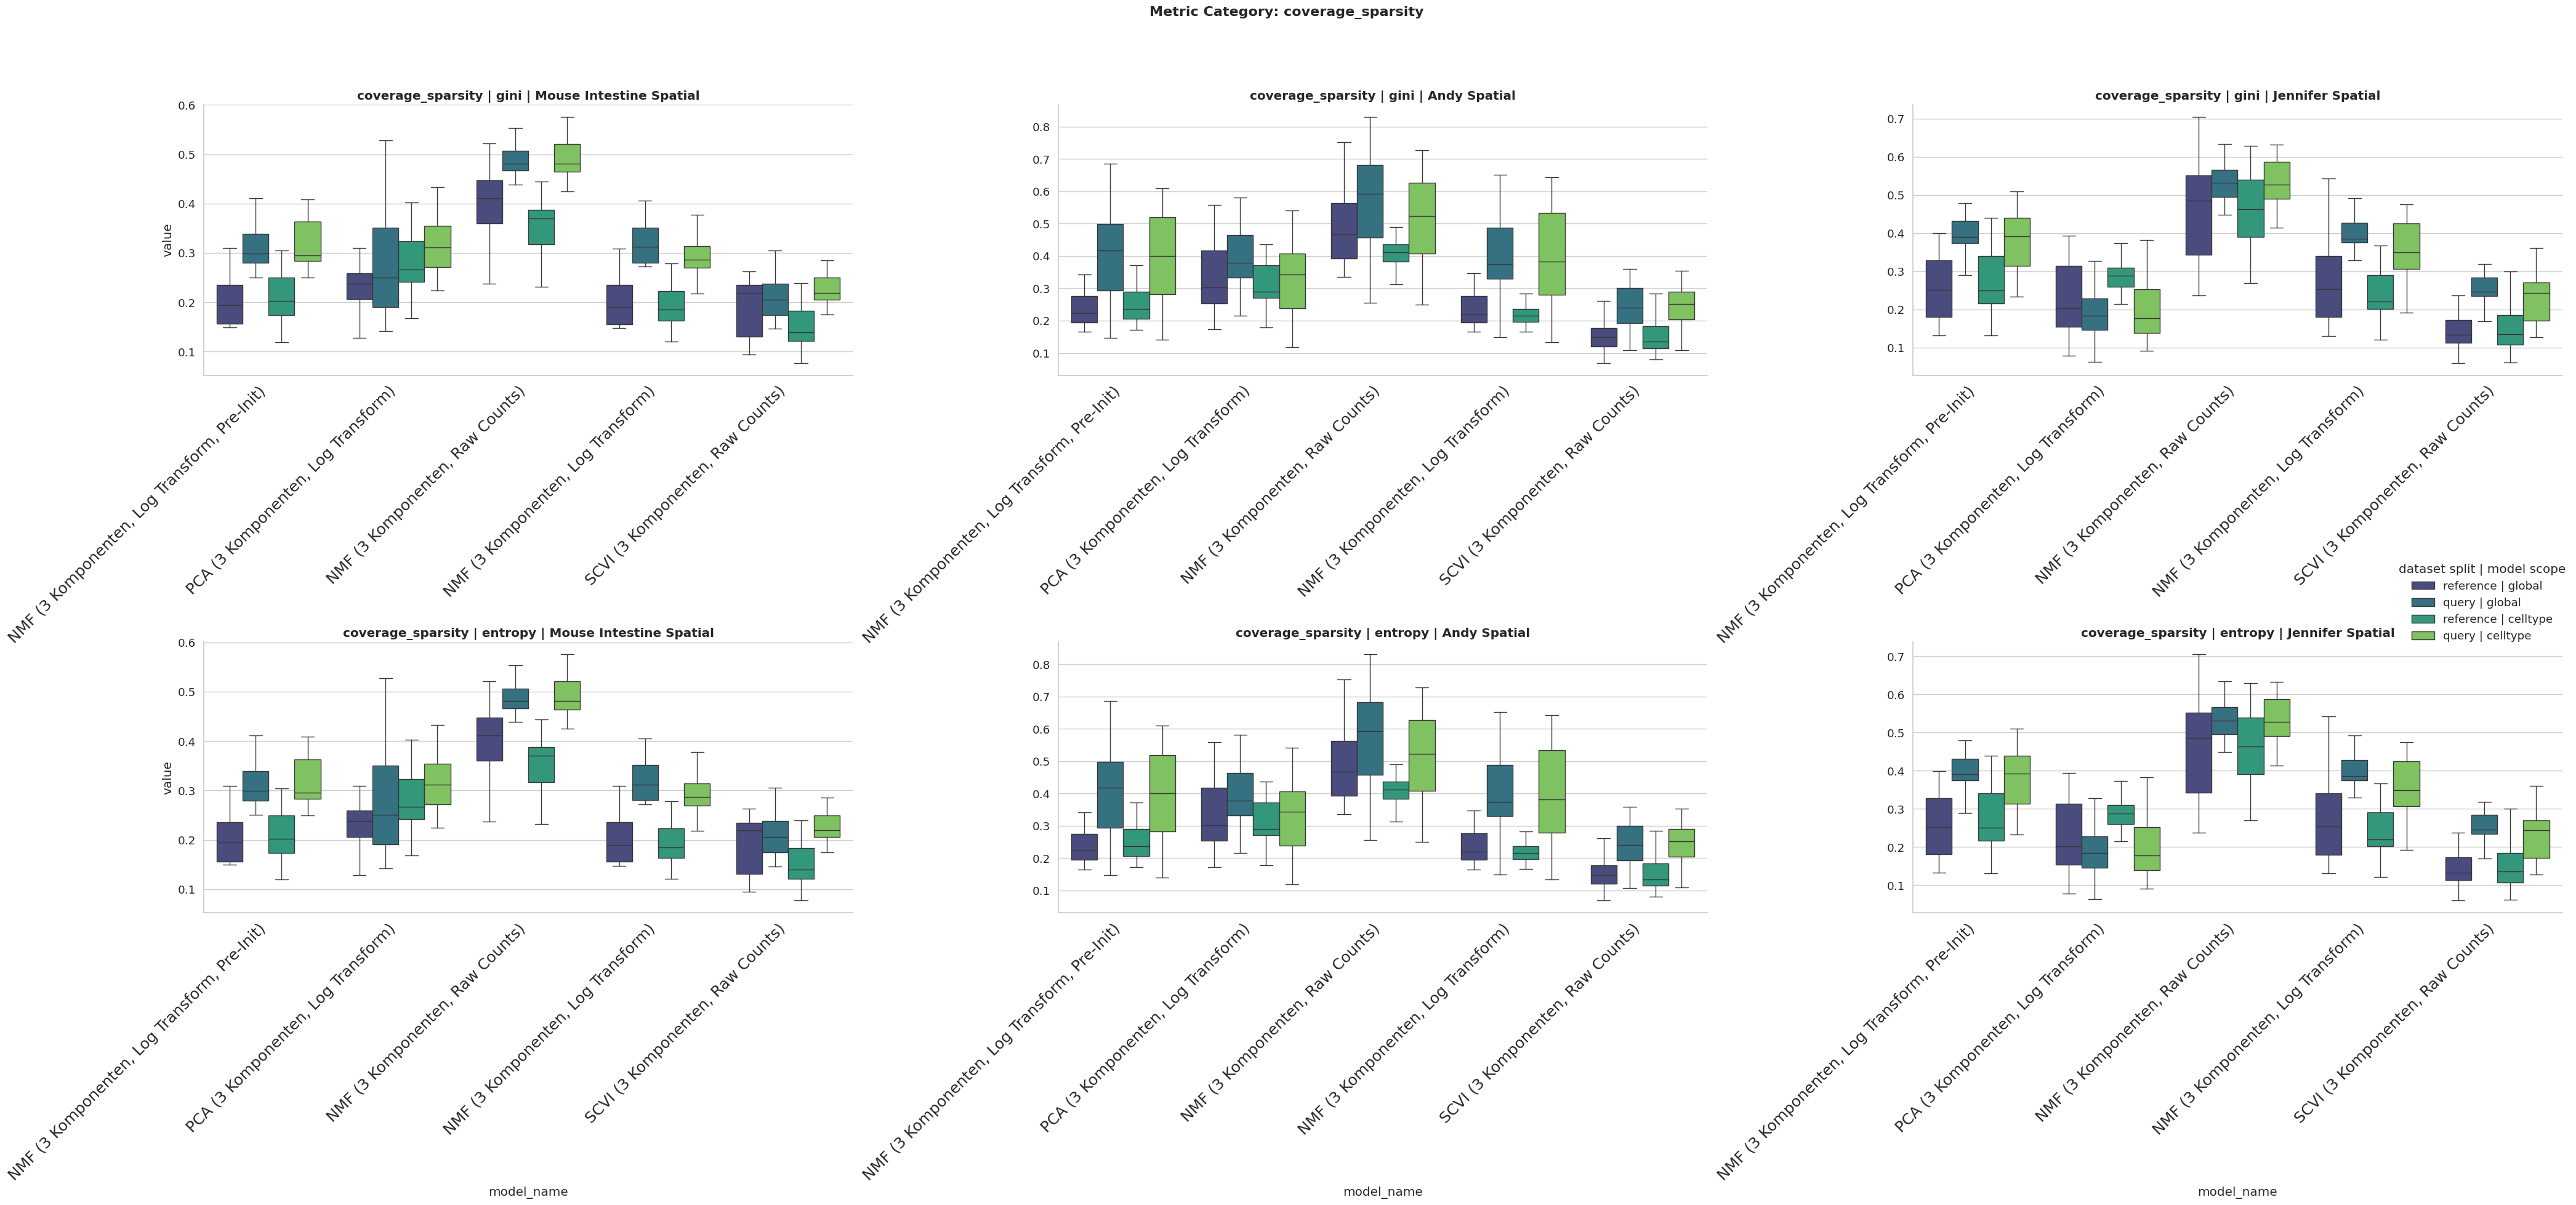

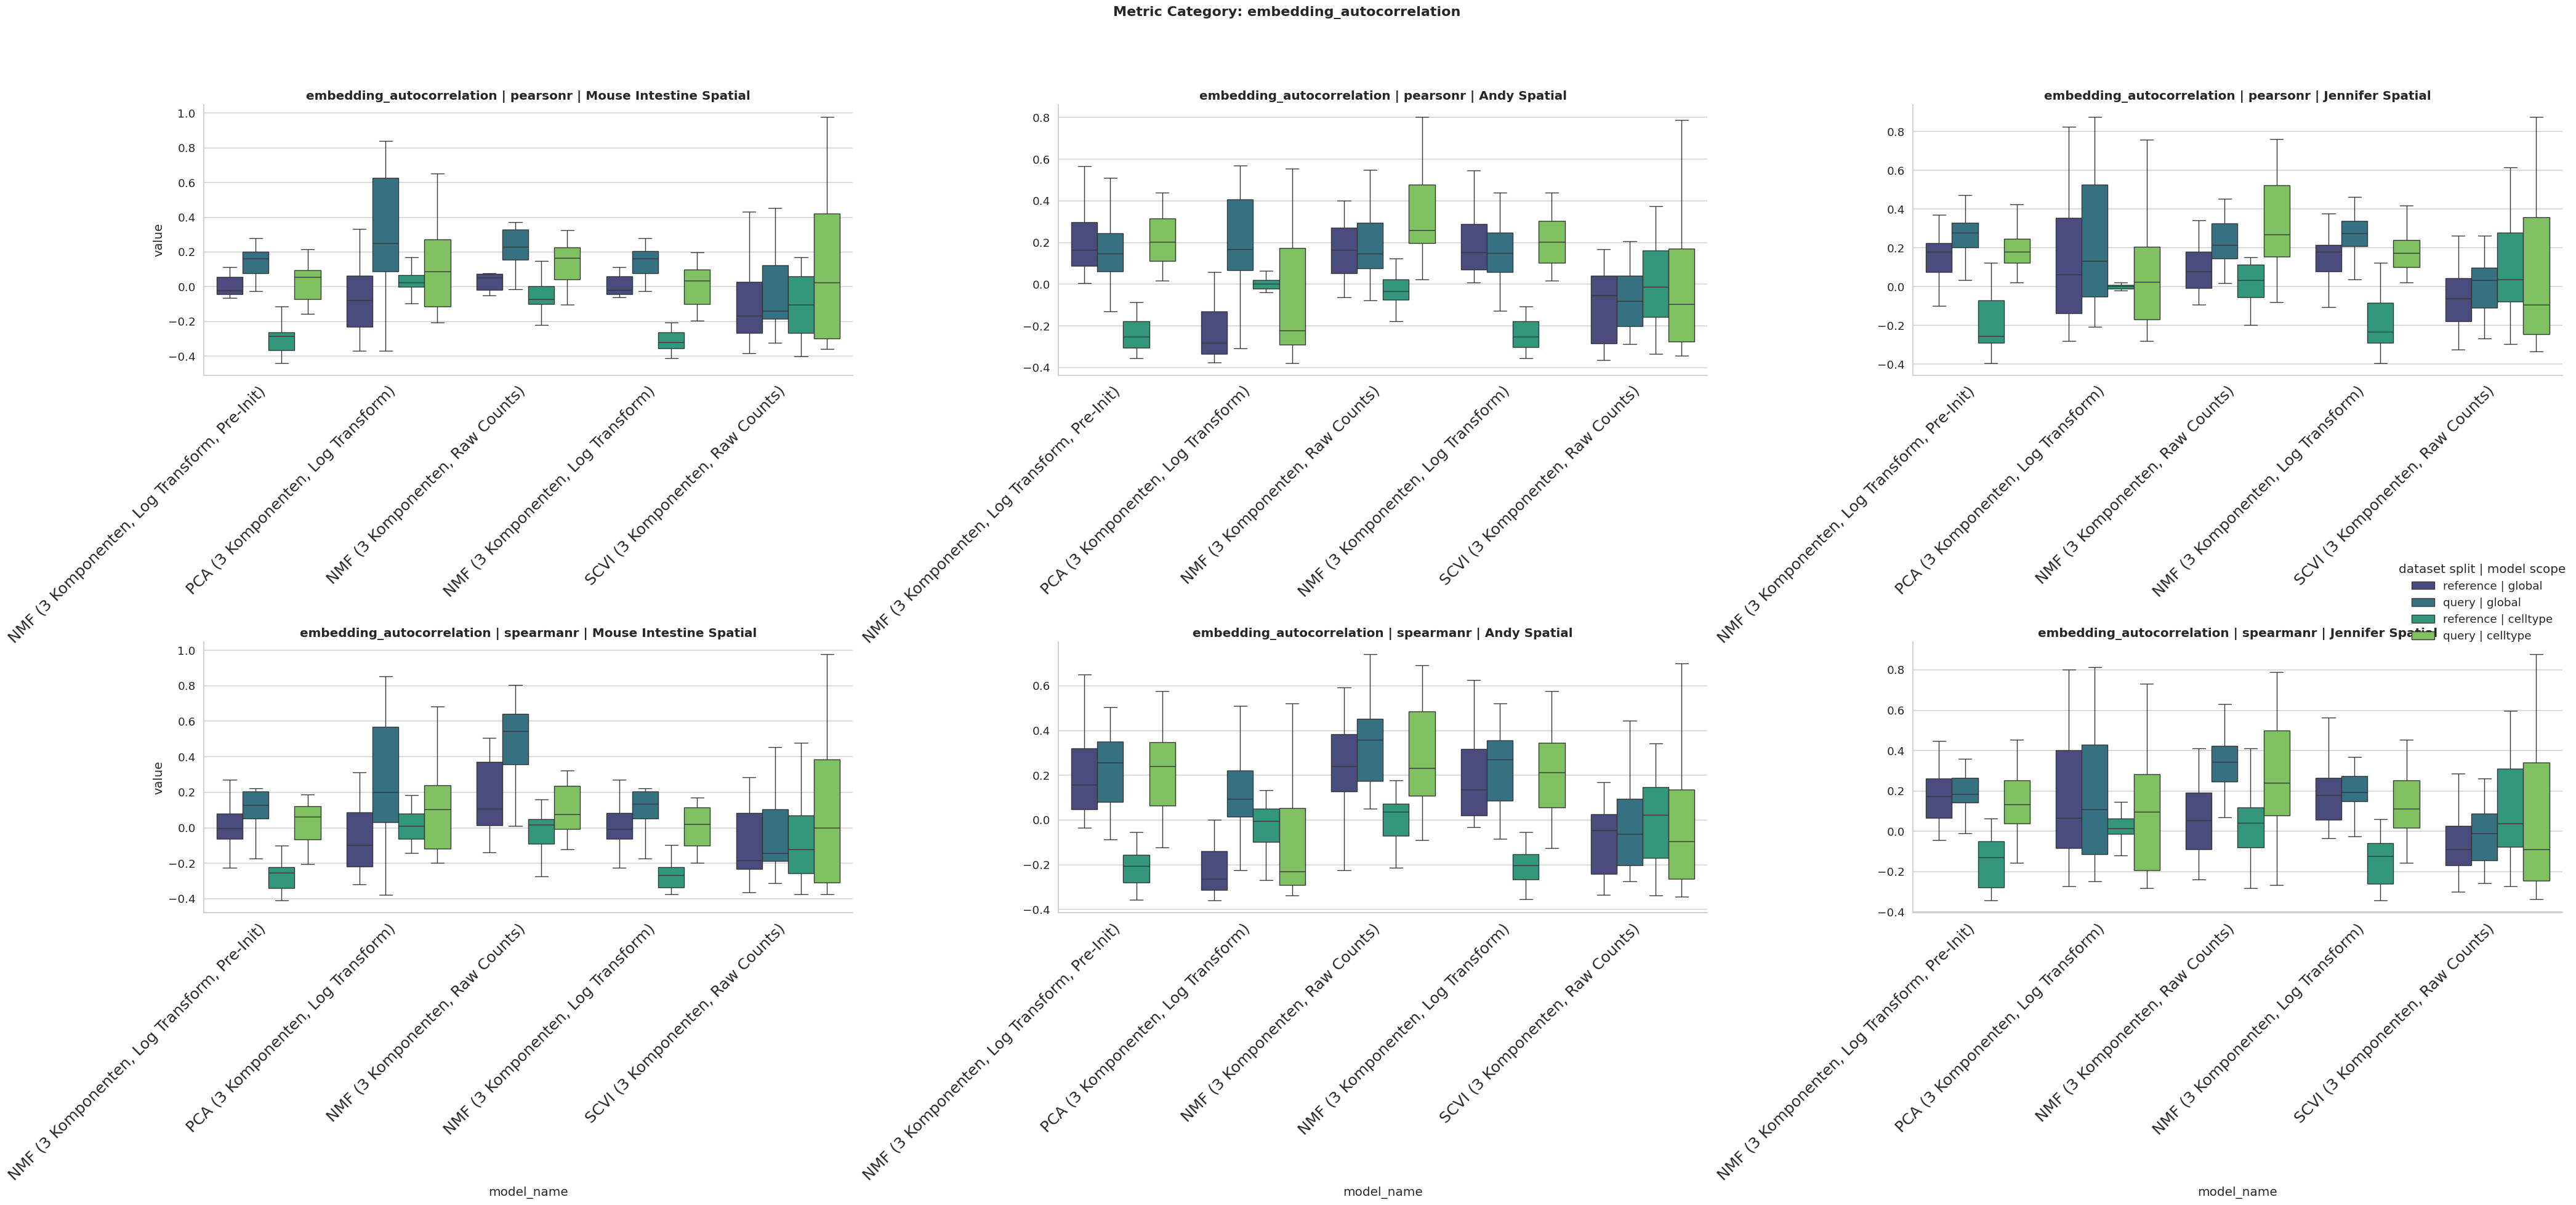

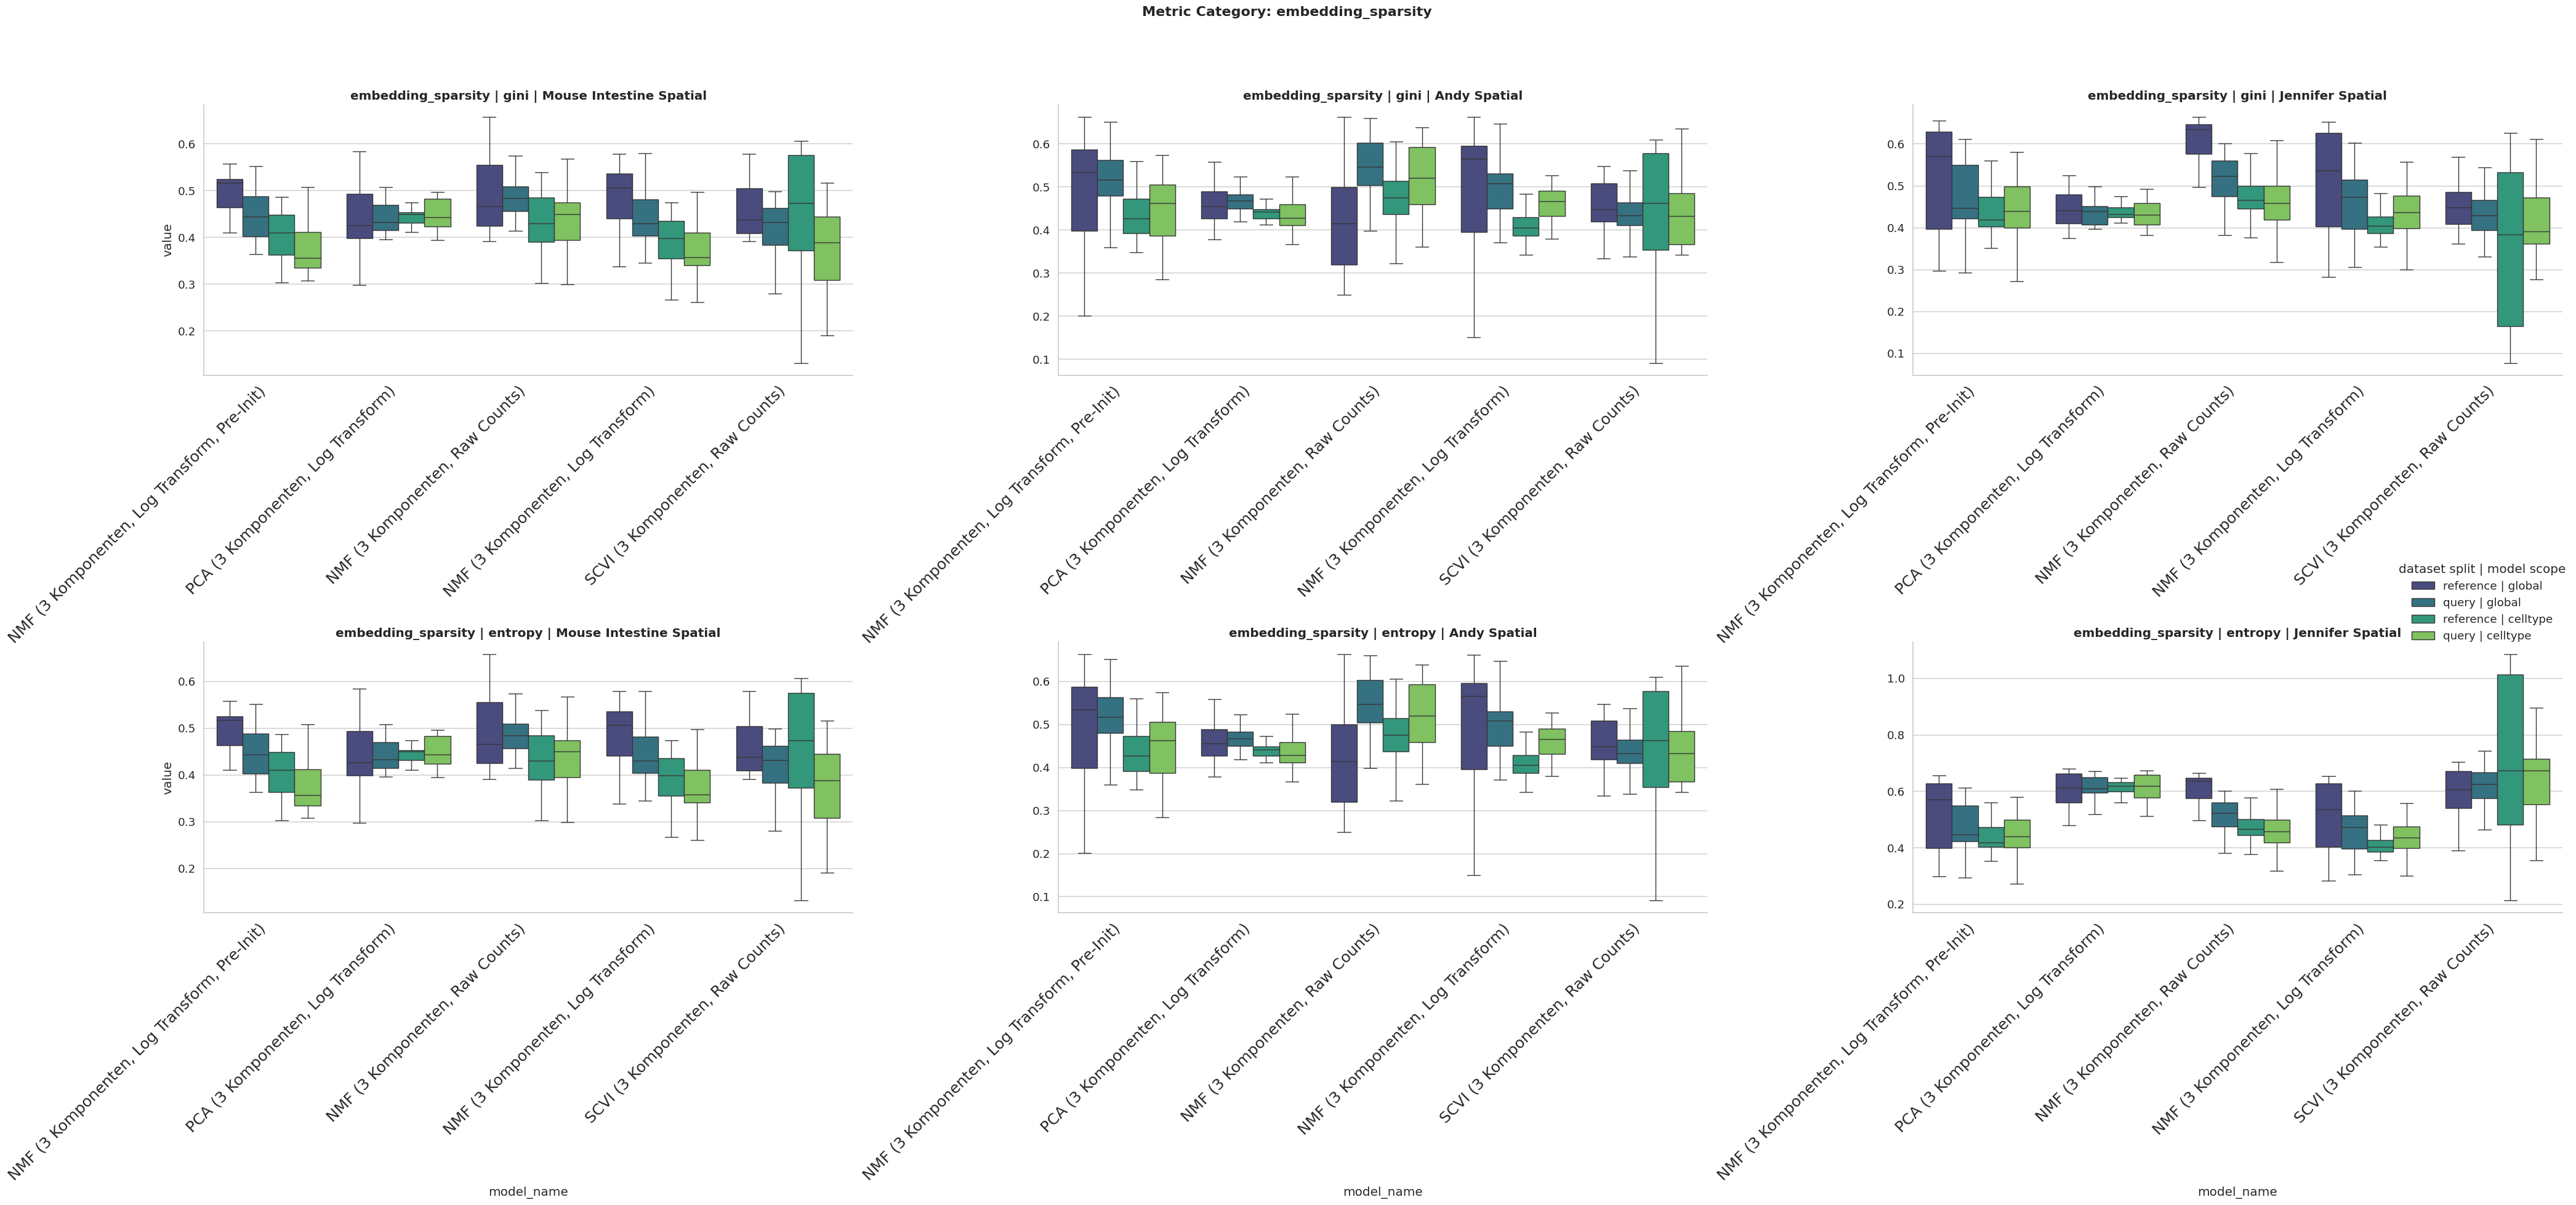

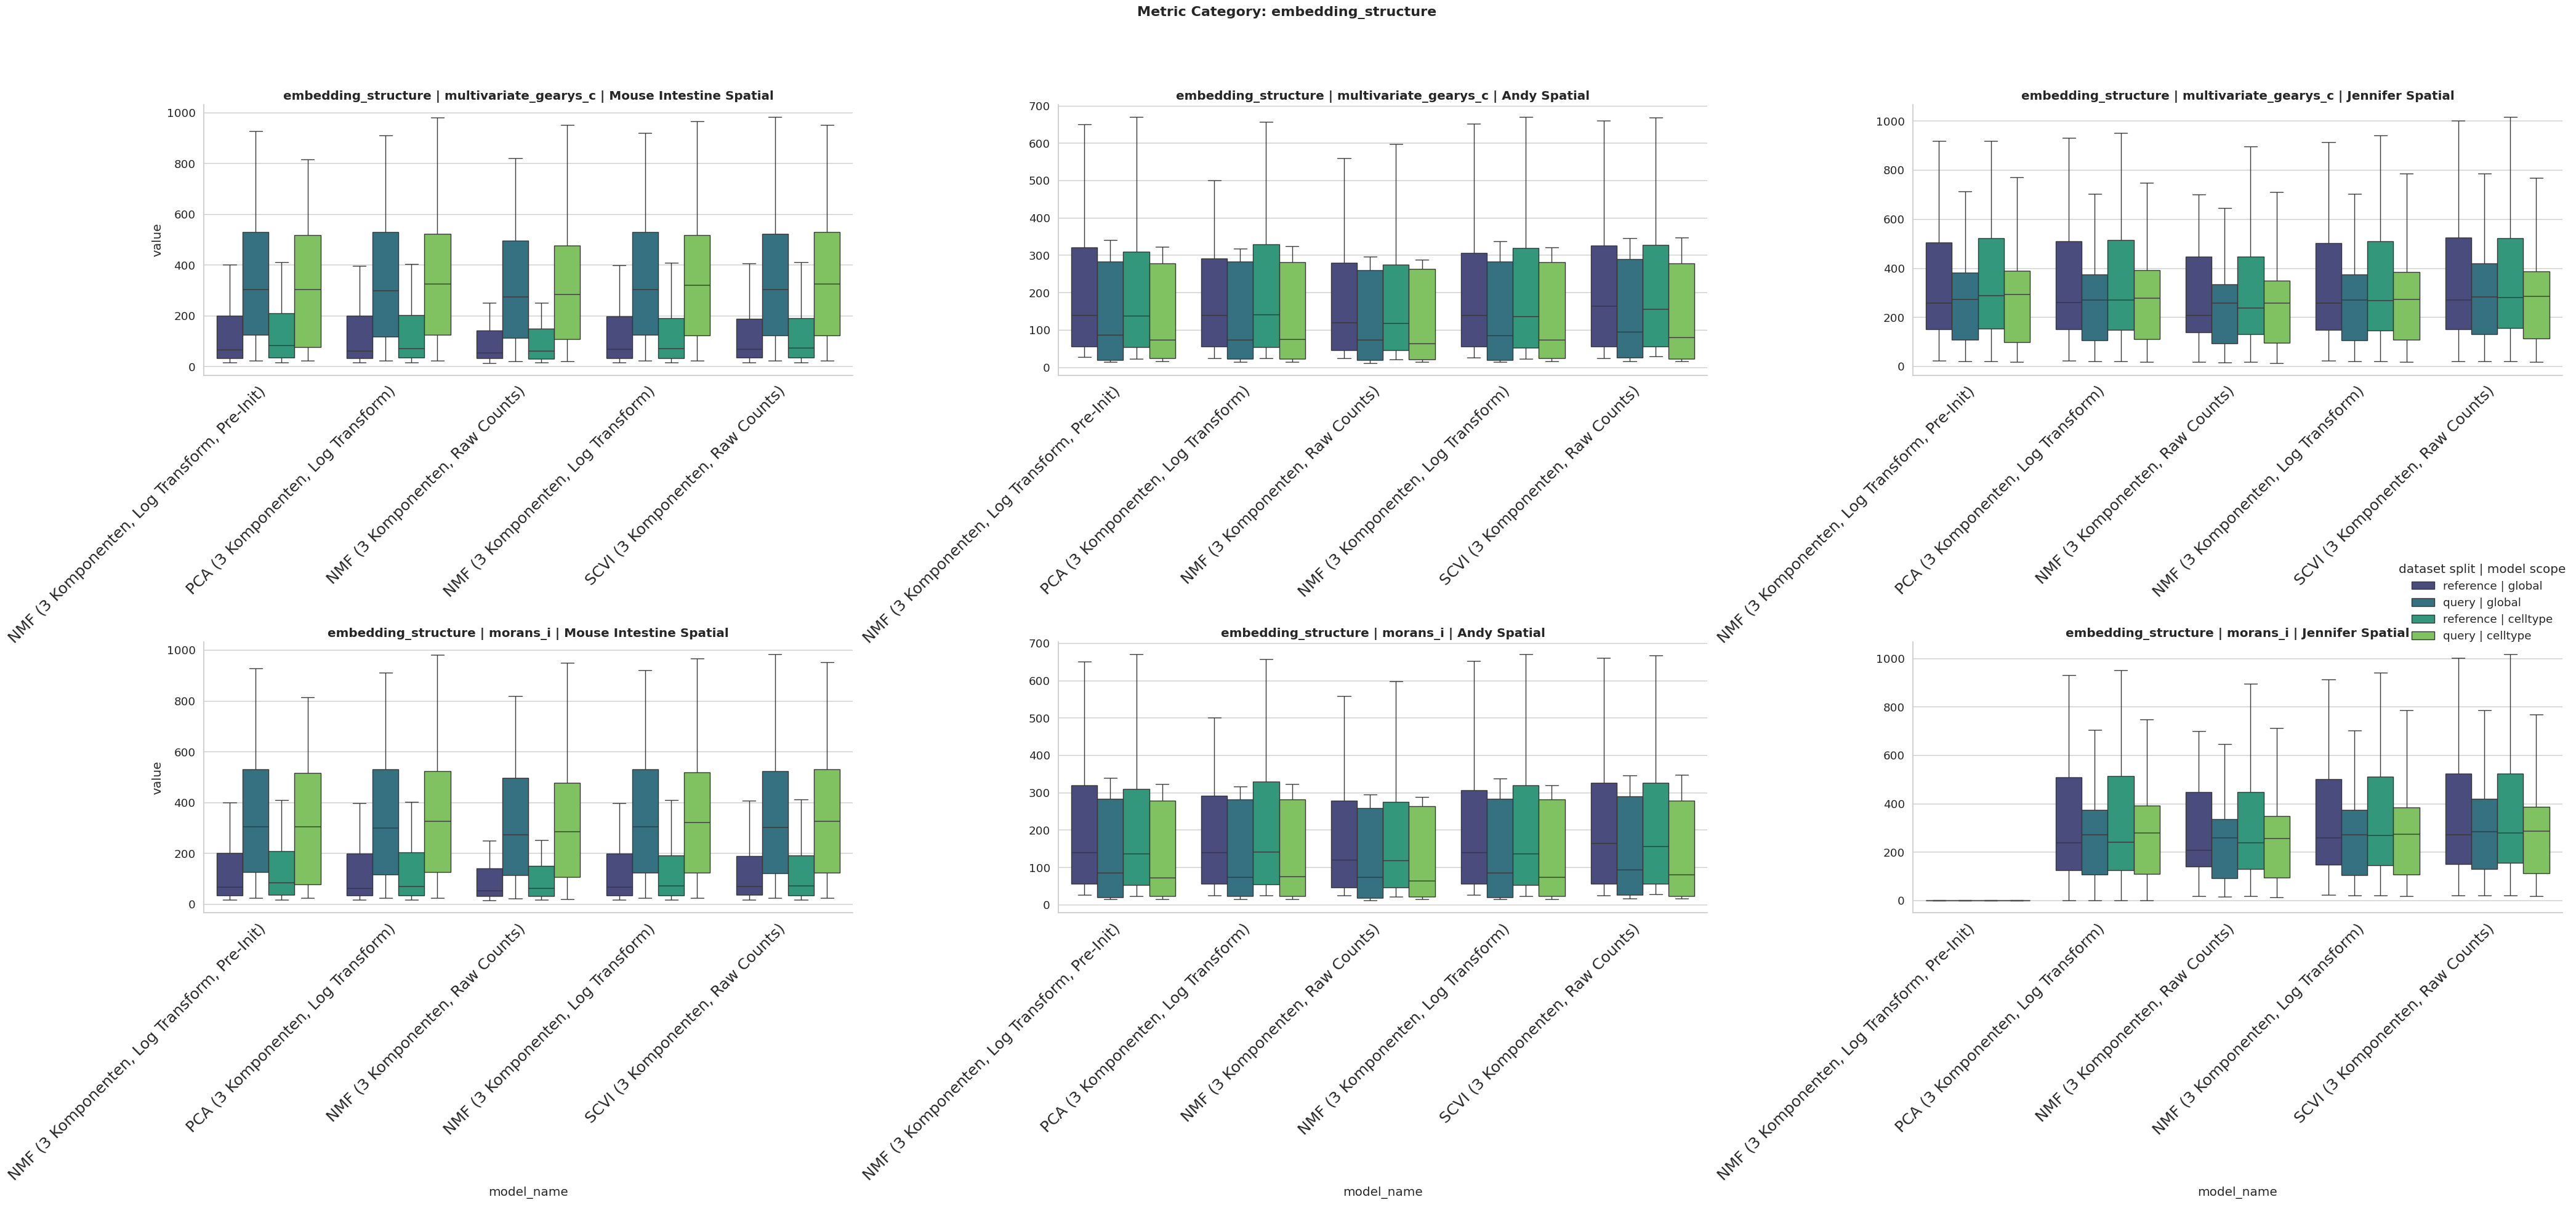

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a clean, publication-style theme
sns.set_theme(style="whitegrid", font_scale=1.2)

for metric_category, sub_df in results_df.groupby("metric_category"):
    g = sns.catplot(
        data=sub_df,
        x="model_name",
        y="value",
        hue="dataset split | model scope",
        kind="box",
        row="metric function",
        col="dataset_name",
        aspect=1.3,
        height=10,
        sharex=False,
        sharey=False,
        showfliers=False,
        palette="viridis", # Professional color palette
        legend_out=True
    )

    g.set_titles(row_template="{row_name}", col_template="{col_name}")

    # 2. Rotate labels and styling
    for ax in g.axes.flat:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=18)

        # Optional: If you want the titles bolded specifically:
        if ax.get_title():
            curr_title = ax.get_title()
            ax.set_title(curr_title, fontweight='bold')

    # 3. Add spacing so titles don't overlap
    g.fig.tight_layout() 
    g.fig.subplots_adjust(top=0.9) 
    g.fig.suptitle(f"Metric Category: {metric_category}", fontsize=16, fontweight='bold')

    plt.show()

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categori

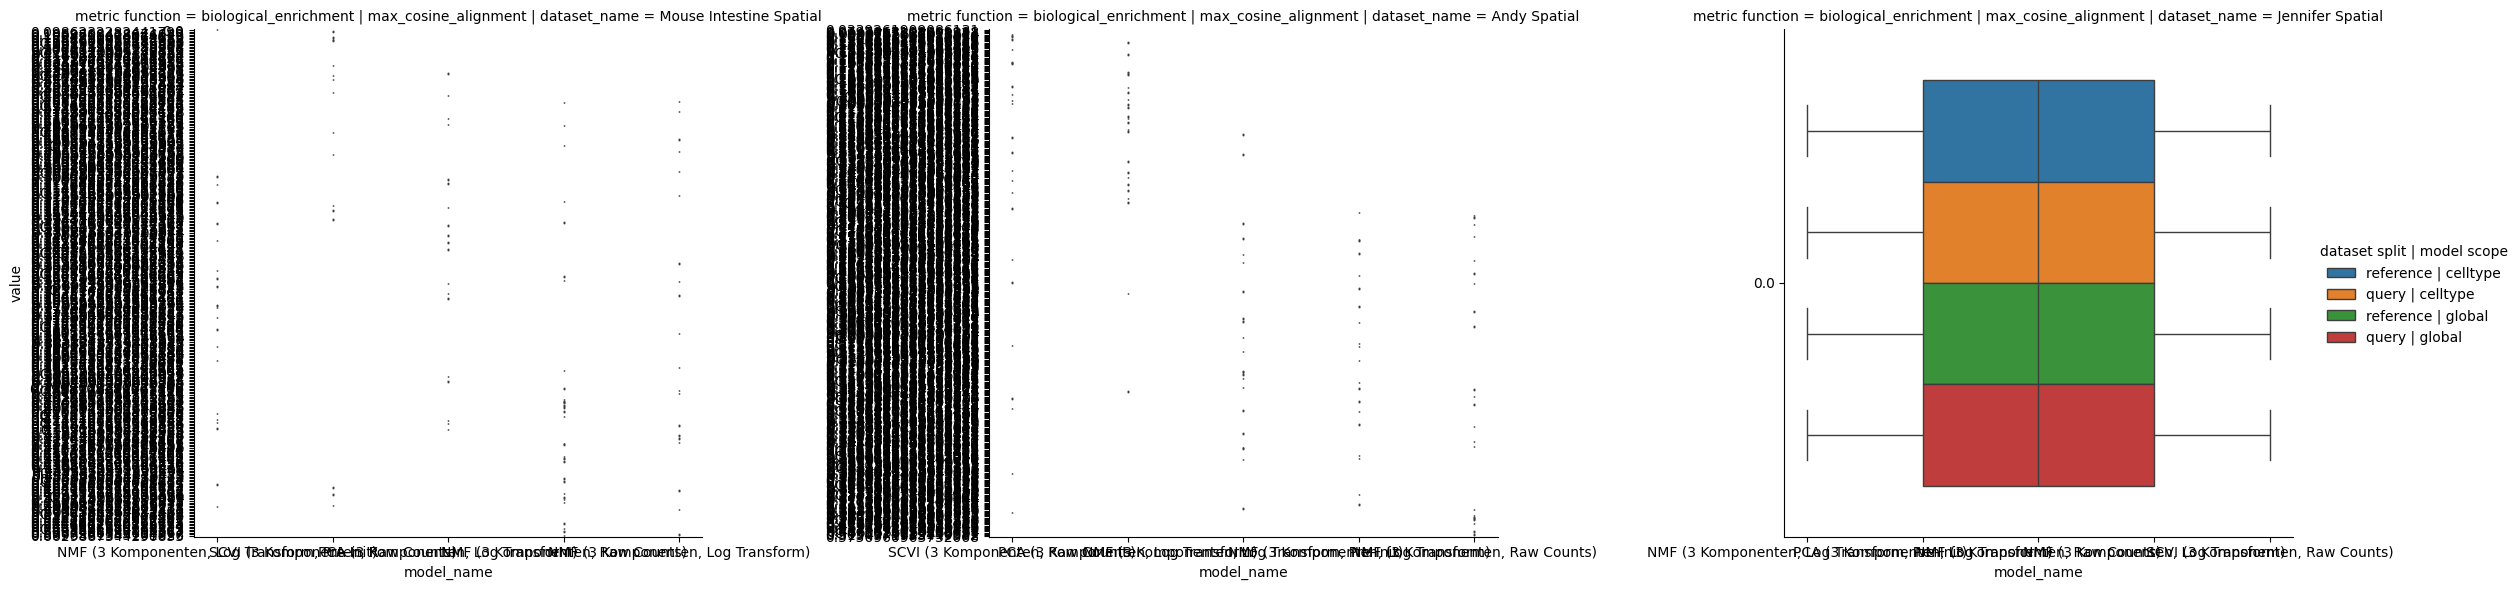

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categori

KeyboardInterrupt: 

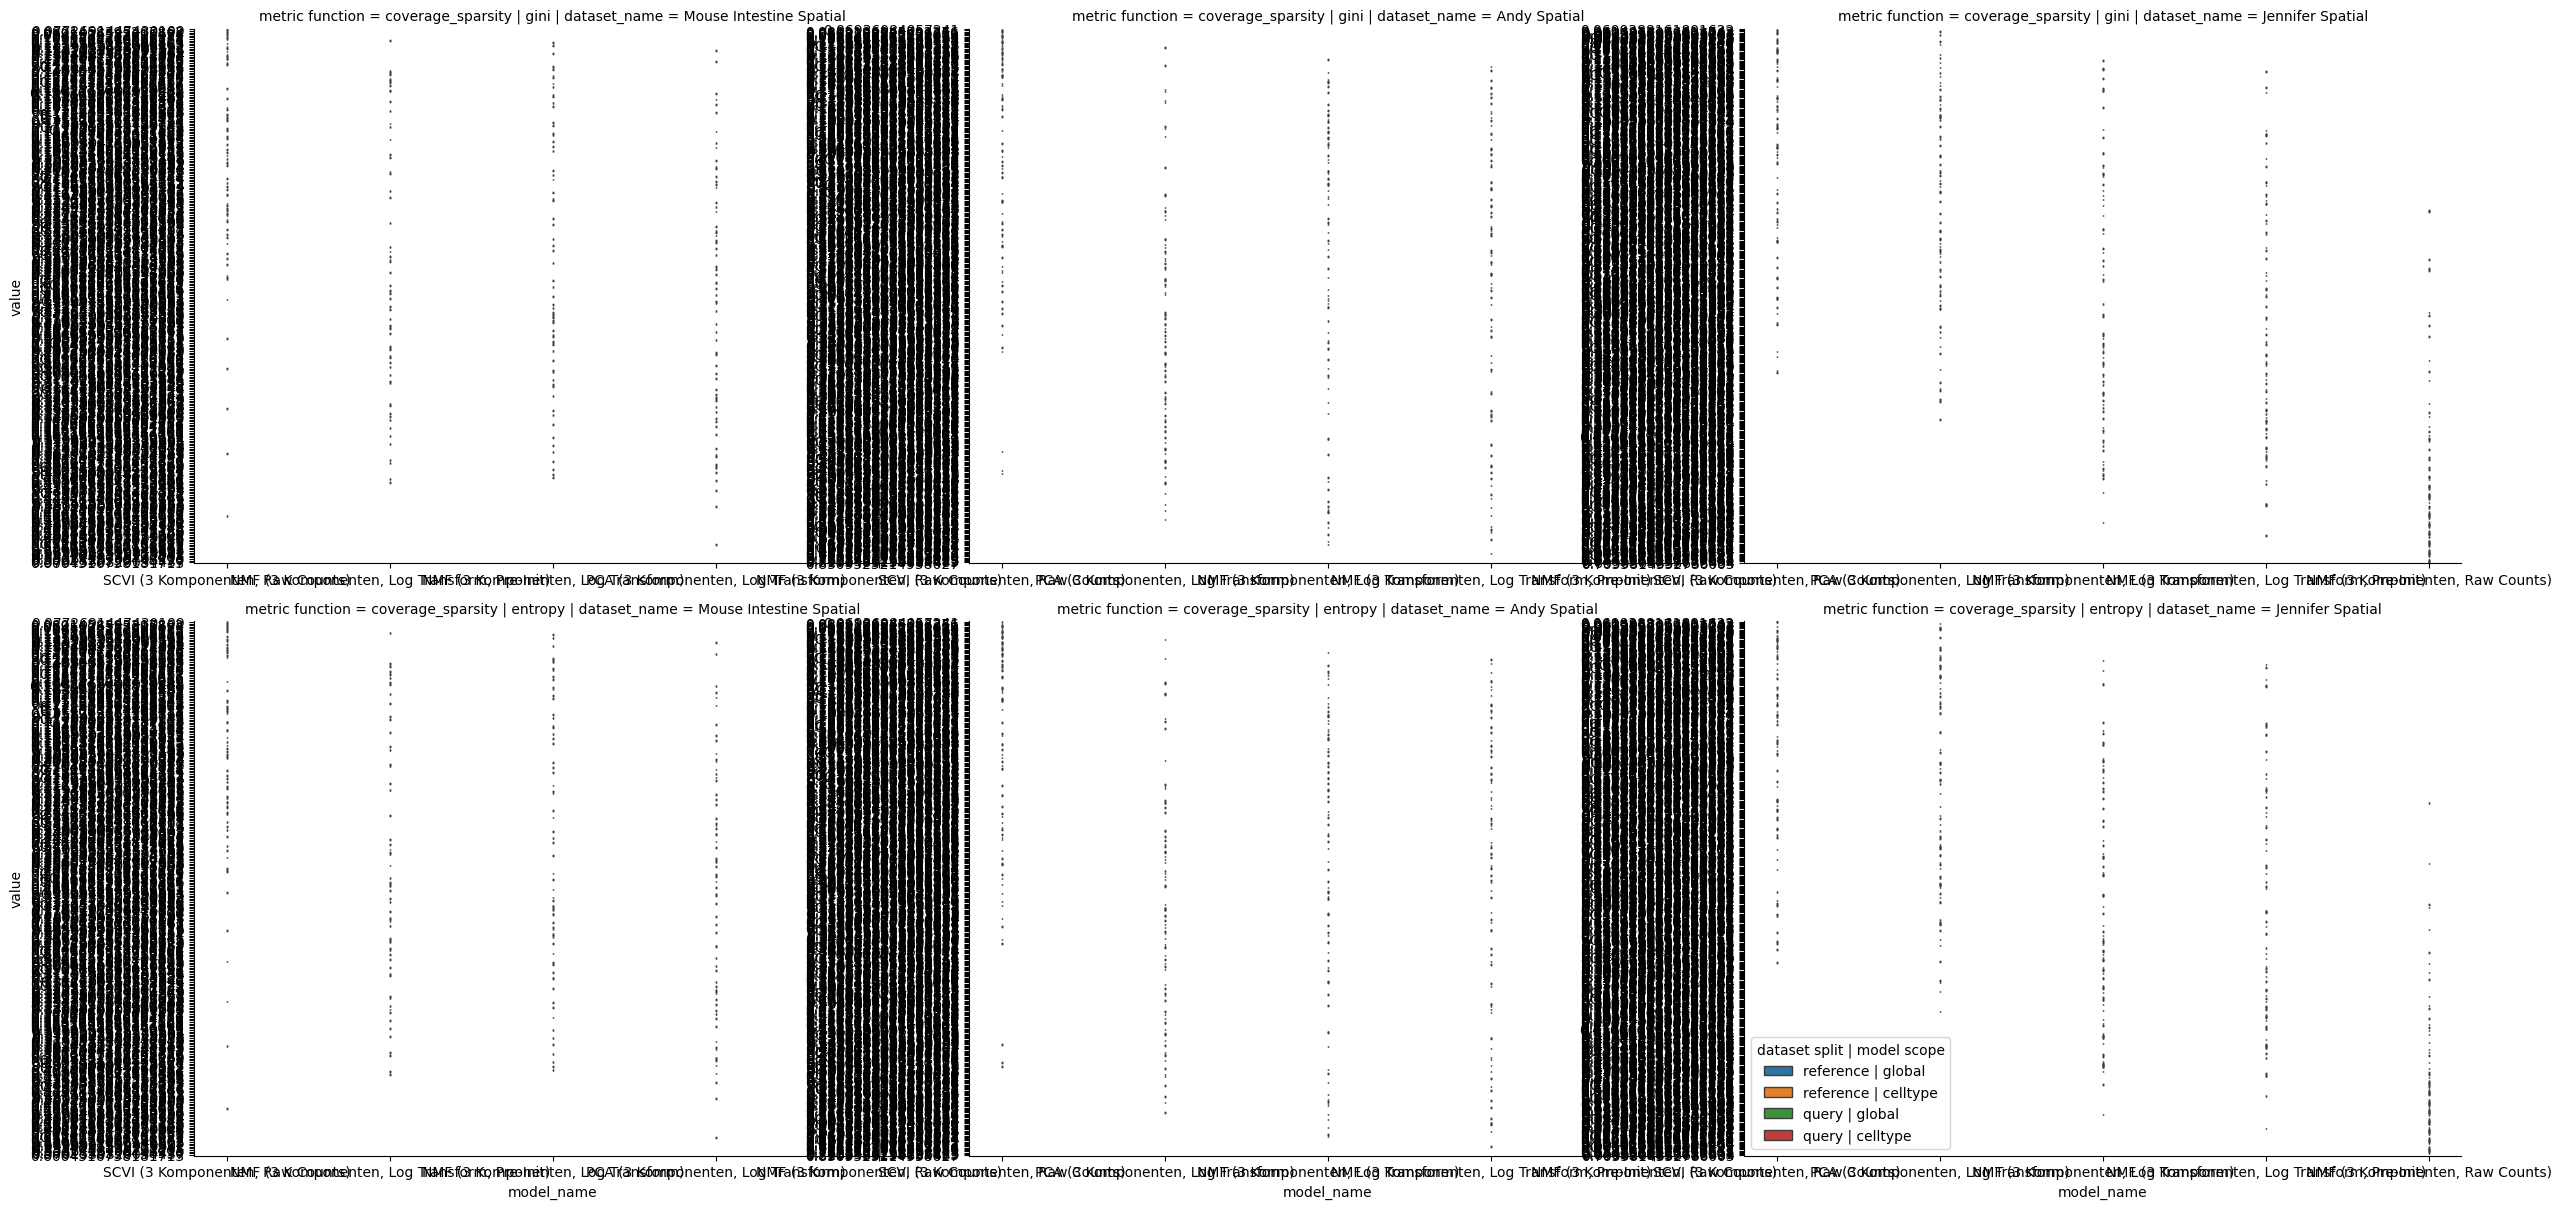

In [32]:
for metric_category, sub_df in results_df.groupby("metric_category"):
    sns.catplot(
        sub_df,
        x="model_name",
        y="value",
        hue="dataset split | model scope",
        kind="box",
        row="metric function",
        col="dataset_name",
        aspect=1.3,
        height=6,
        sharex=False,
        sharey=False,
        showfliers=False,
    )
    plt.show()

In [47]:
import pandas as pd
import plotly.graph_objects as go
from plotly.graph_objs._figure import Figure


def radar_plot(
    df: pd.DataFrame,
    x: str,
    y: str,
    range: tuple[int | float, int | float] | None,
    title: str | None,
) -> Figure:
    # 1. Aggregate data for Median and Quartiles (Q1 and Q3)
    stats: pd.DataFrame = (
        df.groupby(x)[y]
        .agg(
            [
                ("median", "median"),
                ("q1", lambda x: x.quantile(0.25)),
                ("q3", lambda x: x.quantile(0.75)),
            ]
        )
        .reset_index()
    )

    # 2. Extract metrics and close the loop for Plotly
    metrics = stats[x].tolist()
    metrics_closed = metrics + [metrics[0]]

    median_closed = stats["median"].tolist() + [stats["median"].iloc[0]]
    q1_closed = stats["q1"].tolist() + [stats["q1"].iloc[0]]
    q3_closed = stats["q3"].tolist() + [stats["q3"].iloc[0]]

    fig = go.Figure()

    # 3. Add the Lower Bound (Q1) - The reference for the fill
    fig = fig.add_trace(
        go.Scatterpolar(
            r=q1_closed,
            theta=metrics_closed,
            mode="lines",
            line=dict(width=0),
            showlegend=False,
            hoverinfo="skip",
        )
    )

    # 4. Add the Upper Bound (Q3) and fill to 'tonext'
    fig = fig.add_trace(
        go.Scatterpolar(
            r=q3_closed,
            theta=metrics_closed,
            mode="lines",
            line=dict(width=0),
            fill="tonext",
            fillcolor="rgba(0, 100, 255, 0.2)",  # Semi-transparent blue
            name="IQR (Q1-Q3)",
        )
    )

    # 5. Add the Median Line
    fig = fig.add_trace(
        go.Scatterpolar(
            r=median_closed,
            theta=metrics_closed,
            mode="lines+markers",
            line=dict(color="blue", width=3),
            name="Median",
        )
    )

    fig = fig.update_layout(
        polar=dict(
            radialaxis=dict(
                visible=True, range=range, tickfont_size=10, gridcolor="lightgrey"
            )
        ),
        title=title,
    )

    return fig


In [61]:
results_df = results_df.assign(
    normalized_value_transformed=lambda d: d.groupby(
        ["metric function", "dataset_name", "dataset_split", "model_scope"]
    )["value_transformed"].transform(lambda x: (x - x.min()) / (x.max() - x.min()))
)

In [94]:
results_df = results_df.assign(
    z_score_transformed=lambda d: d.groupby(
        ["metric function", "dataset_name", "dataset_split", "model_scope"]
    )["value_transformed"].transform(lambda x: (x - x.mean()) / x.std())
)

In [63]:
import pandas as pd
import plotly.graph_objects as go
from plotly.graph_objs._figure import Figure

def radar_plot_multi(
    df: pd.DataFrame,
    x: str,
    y: str,
    hue: str,
    range_lim: tuple[int | float, int | float] | None = None,
    title: str | None = None,
) -> Figure:
    # 1. Calculate the mean for each metric (x) per category (hue)
    stats = (
        df.groupby([x, hue])[y]
        .mean()
        .reset_index()
    )

    # 2. Get unique metrics and ensure the circle closes
    metrics = sorted(stats[x].unique().tolist())
    metrics_closed = metrics + [metrics[0]]

    fig = go.Figure()

    # 3. Add a trace for each category in 'hue'
    for category in stats[hue].unique():
        category_data = stats[stats[hue] == category]
        
        # Ensure data follows the same order as metrics_closed
        # We reindex to handle potential missing values in specific categories
        values_dict = dict(zip(category_data[x], category_data[y]))
        values = [values_dict.get(m, 0) for m in metrics]
        values_closed = values + [values[0]]

        fig.add_trace(
            go.Scatterpolar(
                r=values_closed,
                theta=metrics_closed,
                mode="lines+markers",
                name=str(category),
                fill='toself', # Optional: adds a light fill under each mean line
                fillcolor='rgba(0,0,0,0)' # Transparent fill by default, change if desired
            )
        )

    # 4. Layout configuration
    fig.update_layout(
        polar=dict(
            radialaxis=dict(
                visible=True, 
                range=range_lim, 
                tickfont_size=10, 
                gridcolor="lightgrey"
            )
        ),
        title=title,
        showlegend=True
    )

    return fig

In [95]:
fig = radar_plot_multi(results_df.query("model_scope == 'celltype' and dataset_split == 'query'"), x="metric function", y="z_score_transformed", hue="model_name")
fig.show()

In [96]:
for (dataset_name,), sub_df in results_df.query("model_scope == 'celltype' and dataset_split == 'query'").groupby(["dataset_name"]):
    print(dataset_name)
    fig = radar_plot_multi(sub_df, x="metric function", y="z_score_transformed", hue="model_name")
    fig.show()

Andy Spatial


Jennifer Spatial


Mouse Intestine Spatial


In [73]:
for (
    model_name, dataset_name
), sub_df in results_df.query("model_scope == 'celltype' and dataset_split == 'query'").groupby(
    ["model_name", "dataset_name"]
):
    fig = radar_plot(
        sub_df,
        x="metric function",
        y="normalized_value_transformed",
        range=None,
        title=model_name + " " + dataset_name
    )
    fig.show()

In [52]:
for (
    model_name,
    dataset_name,
    model_scope,
    dataset_split,
), sub_df in results_df.query("model_scope == 'celltype' and dataset_split == 'query'").groupby(
    ["model_name", "dataset_name", "model_scope", "dataset_split"]
):
    fig = radar_plot(
        sub_df,
        x="metric function",
        y="normalized_value_transformed",
        range=None,
        title=model_name + " " + dataset_name + " " + model_scope + " " + dataset_split,
    )
    fig.show()

In [137]:
results_df

,dataset_name,celltype,sample_id,model_name,metric_category,function_name,model_scope,dataset_split,value,value_transformed,dataset split | model scope,metric function,normalized_value_transformed
0,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,global,reference,0.075507,-0.075507,reference | global,embedding_autocorrelation | pearsonr,0.906387
1,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,global,query,0.371692,-0.371692,query | global,embedding_autocorrelation | pearsonr,0.557120
2,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,celltype,reference,-0.089689,-0.089689,reference | celltype,embedding_autocorrelation | pearsonr,0.910124
3,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,celltype,query,0.139297,-0.139297,query | celltype,embedding_autocorrelation | pearsonr,0.858278
4,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,spearmanr,global,reference,0.107008,-0.107008,reference | global,embedding_autocorrelation | spearmanr,0.868713
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18715,jennifer_data_spatial,pDC,2,scvi_3_raw,coverage_sparsity,gini,celltype,query,0.248340,-0.248340,query | celltype,coverage_sparsity | gini,0.759180
18716,jennifer_data_spatial,pDC,2,scvi_3_raw,coverage_sparsity,entropy,global,reference,5.491333,5.491333,reference | global,coverage_sparsity | entropy,0.553116
18717,jennifer_data_spatial,pDC,2,scvi_3_raw,coverage_sparsity,entropy,global,query,4.822649,4.822649,query | global,coverage_sparsity | entropy,0.429467
18718,jennifer_data_spatial,pDC,2,scvi_3_raw,coverage_sparsity,entropy,celltype,reference,5.665626,5.665626,reference | celltype,coverage_sparsity | entropy,0.618841


In [136]:
df = (
    results_df.groupby(
        [
            "dataset_name",
            "dataset_split",
            "model_scope",
            "function_name",
            "model_name",
            "sample_id",
        ]
    )["value"]
    .mean()
    .reset_index()
)
df

,dataset_name,dataset_split,model_scope,function_name,model_name,sample_id,value
0,andy_data_spatial,query,celltype,entropy,nmf_3_log,0,2.496006
1,andy_data_spatial,query,celltype,entropy,nmf_3_log,1,2.490472
2,andy_data_spatial,query,celltype,entropy,nmf_3_log,2,2.532185
3,andy_data_spatial,query,celltype,entropy,nmf_3_raw,0,2.304340
4,andy_data_spatial,query,celltype,entropy,nmf_3_raw,1,2.291264
...,...,...,...,...,...,...,...
643,mouse_intestine_spatial,reference,global,spearmanr,nmf_3_raw,1,0.145751
644,mouse_intestine_spatial,reference,global,spearmanr,nmf_3_raw,2,0.135316
645,mouse_intestine_spatial,reference,global,spearmanr,scvi_3_raw,0,0.059937
646,mouse_intestine_spatial,reference,global,spearmanr,scvi_3_raw,1,-0.052224


In [31]:
for test, sub_df in df.groupby(
    ["dataset_name", "dataset_split", "model_scope", "function_name"]
):
    pass

In [ ]:
test_df = sub_df.assign(
    # We group ONLY by sample_id to compare models against each other
    rank=lambda x: x["value"].abs().groupby(x["sample_id"]).rank(method="dense")
).sort_values("sample_id")

In [33]:
test_df

,dataset_name,dataset_split,model_scope,function_name,model_name,sample_id,value,rank
963,mouse_intestine_spatial,reference,global,spearmanr,nmf_3_log,0,-0.006223,1.0
966,mouse_intestine_spatial,reference,global,spearmanr,nmf_3_raw,0,0.151443,3.0
969,mouse_intestine_spatial,reference,global,spearmanr,scvi_3_raw,0,0.059937,2.0
964,mouse_intestine_spatial,reference,global,spearmanr,nmf_3_log,1,-0.026651,1.0
970,mouse_intestine_spatial,reference,global,spearmanr,scvi_3_raw,1,-0.052224,2.0
967,mouse_intestine_spatial,reference,global,spearmanr,nmf_3_raw,1,0.145751,3.0
965,mouse_intestine_spatial,reference,global,spearmanr,nmf_3_log,2,-0.010596,1.0
968,mouse_intestine_spatial,reference,global,spearmanr,nmf_3_raw,2,0.135316,2.0
971,mouse_intestine_spatial,reference,global,spearmanr,scvi_3_raw,2,-0.137069,3.0


In [ ]:
radar_plot(df=test_df, x="model_name", y="rank", range=(3, 1), title=None)

In [186]:
sub_df.groupby(["model_name"])["value"].rank().reset_index()

,index,value
0,4,56.0
1,40,53.0
2,76,58.0
3,112,51.0
4,148,47.0
...,...,...
280,10084,20.0
281,10120,14.0
282,10156,4.0
283,10192,46.0


In [ ]:
sub_df.assign(
    # We calculate the rank based on the absolute distance from 0
    rank=lambda x: x["value"].abs().groupby(x["model_name"]).rank(ascending=True)
)

,dataset_name,celltype,sample_id,model_name,metric_category,function_name,model_scope,dataset_split,value,dataset split | model scope,rank
4,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,spearmanr,global,reference,0.129572,reference | global,37.0
40,mouse_intestine_spatial,BZE,1,nmf_3_raw,embedding_autocorrelation,spearmanr,global,reference,0.119345,reference | global,33.0
76,mouse_intestine_spatial,BZE,2,nmf_3_raw,embedding_autocorrelation,spearmanr,global,reference,0.150563,reference | global,42.0
112,mouse_intestine_spatial,BZE,3,nmf_3_raw,embedding_autocorrelation,spearmanr,global,reference,0.118090,reference | global,31.0
148,mouse_intestine_spatial,BZE,4,nmf_3_raw,embedding_autocorrelation,spearmanr,global,reference,0.105785,reference | global,27.0
...,...,...,...,...,...,...,...,...,...,...,...
10084,mouse_intestine_spatial,pDC,0,scvi_3_raw,embedding_autocorrelation,spearmanr,global,reference,-0.206863,reference | global,57.0
10120,mouse_intestine_spatial,pDC,1,scvi_3_raw,embedding_autocorrelation,spearmanr,global,reference,-0.250000,reference | global,68.0
10156,mouse_intestine_spatial,pDC,2,scvi_3_raw,embedding_autocorrelation,spearmanr,global,reference,-0.309804,reference | global,78.0
10192,mouse_intestine_spatial,pDC,3,scvi_3_raw,embedding_autocorrelation,spearmanr,global,reference,-0.035294,reference | global,11.0


In [26]:
ranked_df = (
    results_df.groupby(
        [
            "dataset_name",
            "function_name",
            "metric_category",
            "sample_id",
            "dataset_split",
            "model_scope",
            "celltype",
        ]
    )["value_transformed"]
    .rank()  # pct=True gives a 0-1 scale automatically
    .reset_index(name="rank")  # Rename rank to 'value' so the radar_plot function works
    .merge(results_df.drop(columns="value"), left_index=True, right_index=True)
)
ranked_df

,index,rank,dataset_name,celltype,sample_id,model_name,metric_category,function_name,model_scope,dataset_split,value_transformed,dataset split | model scope,metric function,normalized_value_transformed
0,0,3.0,Mouse Intestine Spatial,BZE,0,"NMF (3 Komponenten, Log Transform, Pre-Init)",embedding_autocorrelation,pearsonr,global,reference,-0.1,reference | global,embedding_autocorrelation | pearsonr,NaN
1,1,3.0,Mouse Intestine Spatial,BZE,0,"NMF (3 Komponenten, Log Transform, Pre-Init)",embedding_autocorrelation,pearsonr,global,query,-0.2,query | global,embedding_autocorrelation | pearsonr,NaN
2,2,3.0,Mouse Intestine Spatial,BZE,0,"NMF (3 Komponenten, Log Transform, Pre-Init)",embedding_autocorrelation,pearsonr,celltype,reference,-0.3,reference | celltype,embedding_autocorrelation | pearsonr,NaN
3,3,3.0,Mouse Intestine Spatial,BZE,0,"NMF (3 Komponenten, Log Transform, Pre-Init)",embedding_autocorrelation,pearsonr,celltype,query,-0.4,query | celltype,embedding_autocorrelation | pearsonr,NaN
4,4,3.0,Mouse Intestine Spatial,BZE,0,"NMF (3 Komponenten, Log Transform, Pre-Init)",embedding_autocorrelation,spearmanr,global,reference,-0.1,reference | global,embedding_autocorrelation | spearmanr,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11335,11335,3.0,Jennifer Spatial,pDC,0,"SCVI (3 Komponenten, Raw Counts)",coverage_sparsity,entropy,celltype,query,0.4,query | celltype,coverage_sparsity | entropy,NaN
11336,11336,3.0,Jennifer Spatial,pDC,0,"SCVI (3 Komponenten, Raw Counts)",biological_enrichment,max_cosine_alignment,global,reference,0.1,reference | global,biological_enrichment | max_cosine_alignment,NaN
11337,11337,3.0,Jennifer Spatial,pDC,0,"SCVI (3 Komponenten, Raw Counts)",biological_enrichment,max_cosine_alignment,global,query,0.2,query | global,biological_enrichment | max_cosine_alignment,NaN
11338,11338,3.0,Jennifer Spatial,pDC,0,"SCVI (3 Komponenten, Raw Counts)",biological_enrichment,max_cosine_alignment,celltype,reference,0.3,reference | celltype,biological_enrichment | max_cosine_alignment,NaN


In [27]:
for (model_name, dataset_name, model_scope, dataset_split), sub_df in ranked_df.groupby(
    ["model_name", "dataset_name", "model_scope", "dataset_split"]
):
    fig = radar_plot(
        sub_df,
        x="metric function",
        y="rank",
        range=None,
        title=model_name + " " + dataset_name + " " + model_scope + " " + dataset_split,
    )
    fig.show()

In [ ]:
radar_plot(sub_df, x="function_name", y="value", range=None, title=model_name)

In [118]:
from plotly.subplots import make_subplots

# 1. Prepare the data (Normalization)
normalized_df = results_df.assign(
    value=lambda d: d.groupby("function_name")["value"].transform(
        lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0.5
    )
)

# 2. Define your grid dimensions
row_values = normalized_df["model_name"].unique()
col_values = normalized_df["dataset_name"].unique()

# 3. Initialize the grid with polar specs
fig_grid = make_subplots(
    rows=len(row_values),
    cols=len(col_values),
    row_titles=list(row_values),
    column_titles=list(col_values),
    specs=[[{"type": "polar"} for _ in col_values] for _ in row_values],
    vertical_spacing=0.08,
    horizontal_spacing=0.08,
)

# 4. Outer scope loop calling your original function
for r_idx, row_val in enumerate(row_values, 1):
    for c_idx, col_val in enumerate(col_values, 1):
        # Slice data for this specific cell
        subset = normalized_df[
            (normalized_df["model_name"] == row_val)
            & (normalized_df["dataset_name"] == col_val)
        ]

        if not subset.empty:
            # Call your original function
            temp_fig = radar_plot(
                subset, x="function_name", y="value", range=(0, 1), title=None
            )

            # Extract traces from the returned figure and add them to the grid
            for trace in temp_fig.data:
                # Turn off individual legends to avoid clutter
                trace.showlegend = False
                fig_grid.add_trace(trace, row=r_idx, col=c_idx)

# 5. Final Styling
fig_grid.update_layout(
    height=350 * len(row_values),
    width=350 * len(col_values),
    title_text="Metric Performance Grid (Normalized)",
    template="plotly_white",
)

# Ensure all radial axes in the grid respect the 0-1 range
fig_grid.update_polars(radialaxis=dict(range=[0, 1], visible=True))

fig_grid.show()

In [147]:
results_df

,dataset_name,celltype,sample_id,model_name,metric_category,function_name,model_scope,dataset_split,value,dataset split | model scope
0,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,global,reference,0.079251,reference | global
1,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,global,query,0.325079,query | global
2,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,celltype,reference,-0.089689,reference | celltype
3,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,celltype,query,0.148808,query | celltype
4,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,spearmanr,global,reference,0.129572,reference | global
...,...,...,...,...,...,...,...,...,...,...
20515,mouse_intestine_pseudospatial,pDC,4,scvi_3_raw,embedding_sparsity,kurtosis,celltype,query,-1.500000,query | celltype
20516,mouse_intestine_pseudospatial,pDC,4,scvi_3_raw,embedding_sparsity,skew,global,reference,0.618465,reference | global
20517,mouse_intestine_pseudospatial,pDC,4,scvi_3_raw,embedding_sparsity,skew,global,query,-0.010462,query | global
20518,mouse_intestine_pseudospatial,pDC,4,scvi_3_raw,embedding_sparsity,skew,celltype,reference,-0.703908,reference | celltype
